# LLM Evaluation
Sends anonimized or artificial medical records to external LLM apis for structured feedback. Due to personal data restriction, personal (real) notes can not be sent to openai, claude etc. Instead, anonymized notes or use local LLMs. 
Writes verdicts to `outputs/feedback/`. 

You will need to have an OpenAI API key to run this notebook. Or You can connect with a bigger local LLM. 

In [ ]:


import json
import os
import openai
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")



if not OPENAI_API_KEY:
    raise EnvironmentError(
        "Set the OPENAI_API_KEY environment variable before running this notebook."
    )

client = openai.OpenAI(api_key=OPENAI_API_KEY)

Path("../outputs/feedback").mkdir(parents=True, exist_ok=True)


def ask(system: str, user: str) -> dict:
    r = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {
                "role": "system",
                "content": system + "\nReturn ONLY valid JSON. No markdown."
            },
            {
                "role": "user",
                "content": user
            }
        ],
        max_tokens=800,
        temperature=0.0,
    )

    text = r.choices[0].message.content.strip()

    # Remove ```json wrappers if the model adds them
    if text.startswith("```"):
        text = text.replace("```json", "")
        text = text.replace("```", "")
        text = text.strip()

    return json.loads(text)


In [4]:
DEID_SYS = """
You are a clinical privacy expert. Evaluate de-identification quality.

Bracketed placeholders such as
[first_name],
[last_name],
[date_of_birth],
[phone_number],
[pin],
[medical_record_number],
[email]
represent successful redactions and must NOT be reported as missed PII.

Evaluate:
1. Whether any identifiable information remains visible.
2. Whether non-PII clinical information was unnecessarily removed.
3. Overall privacy risk.

Return ONLY valid JSON:

{
  "verdict": "PASS" | "REVIEW" | "FAIL",
  "missed_pii": [],
  "over_redacted": [],
  "confidence": 0.0,
  "note": ""
}
"""


NER_SYS = """
You are a clinical NLP expert. Evaluate clinical entity extraction quality.

Consider:
1. Important clinical concepts that were missed.
2. Incorrect labels.
3. False positives.
4. Fragmented entities.

Return ONLY valid JSON:

{
  "verdict": "GOOD" | "ACCEPTABLE" | "POOR",
  "missed": [],
  "wrong_label": [],
  "false_positives": [],
  "confidence": 0.0,
  "note": ""
}
"""


deid_results = []
ner_results = []

PRIVACY_DIR = Path("../outputs/privacy")
MEDICAL_DIR = Path("../outputs/medical")
FEEDBACK_DIR = Path("../outputs/feedback")

for pf in sorted(PRIVACY_DIR.glob("*_privacy.json")):
    note_id = pf.stem.replace("_privacy", "")

    priv = json.loads(pf.read_text())
    mf = MEDICAL_DIR / f"{note_id}_medical.json"

    # ------------------------
    # DeID evaluation
    # ------------------------
    try:
        prompt = (
            f"ORIGINAL:\n{priv['original_text']}\n\n"
            f"REDACTED:\n{priv['redacted_text']}\n\n"
            f"PII:\n{json.dumps(priv['pii_entities'], indent=2)}"
        )

        v = ask(DEID_SYS, prompt)
        v["note_id"] = note_id
        deid_results.append(v)

        (FEEDBACK_DIR / f"{note_id}_deid.json").write_text(
            json.dumps(v, indent=2)
        )

        print(f"{note_id}: deid={v['verdict']} ({v['confidence']})")

    except Exception as e:
        print(f"{note_id}: deid ERROR {e}")

    # ------------------------
    # NER evaluation
    # ------------------------
    if mf.exists():
        try:
            med = json.loads(mf.read_text())

            prompt = (
                f"NOTE:\n{med['redacted_text']}\n\n"
                f"ENTITIES:\n{json.dumps(med['entities'], indent=2)}"
            )

            v = ask(NER_SYS, prompt)
            v["note_id"] = note_id
            ner_results.append(v)

            (FEEDBACK_DIR / f"{note_id}_ner.json").write_text(
                json.dumps(v, indent=2)
            )

            print(f"{note_id}: ner={v['verdict']} ({v['confidence']})")

        except Exception as e:
            print(f"{note_id}: ner ERROR {e}")

note_001_copd: deid=REVIEW (0.0)
note_001_copd: ner=ACCEPTABLE (0.0)
note_002_ra: deid=REVIEW (0.0)
note_002_ra: ner=ACCEPTABLE (0.0)
note_003_ami: deid=REVIEW (0.0)
note_003_ami: ner=ACCEPTABLE (0.0)
note_004_diabetes: deid=REVIEW (0.0)
note_004_diabetes: ner=ACCEPTABLE (0.0)
note_005_oncology: deid=REVIEW (0.0)
note_005_oncology: ner=ACCEPTABLE (0.0)
note_006_stroke: deid=REVIEW (0.0)
note_006_stroke: ner=ACCEPTABLE (0.0)
note_007_sepsis: deid=REVIEW (0.0)
note_007_sepsis: ner=ACCEPTABLE (0.0)
note_008_depression: deid=REVIEW (0.0)
note_008_depression: ner=ACCEPTABLE (0.0)
note_009_ckd: deid=REVIEW (0.0)
note_009_ckd: ner=ACCEPTABLE (0.0)
note_010_asthma_paeds: deid=REVIEW (0.0)
note_010_asthma_paeds: ner=ACCEPTABLE (0.0)
note_green: deid=REVIEW (0.0)
note_green: ner=POOR (0.0)
note: deid=REVIEW (0.0)
note: ner=ACCEPTABLE (0.0)


,note_id,verdict,confidence,note
0,note_001_copd,REVIEW,0.0,The de-identification process redacted most of...
1,note_002_ra,REVIEW,0.0,The de-identification process needs to be revi...
2,note_003_ami,REVIEW,0.0,The de-identification process has partially su...
3,note_004_diabetes,REVIEW,0.0,The de-identification process has partially re...
4,note_005_oncology,REVIEW,0.0,Some identifiable information has been success...
5,note_006_stroke,REVIEW,0.0,The de-identification process needs to be revi...
6,note_007_sepsis,REVIEW,0.0,The de-identification process needs to be revi...
7,note_008_depression,REVIEW,0.0,The de-identification process has partially re...
8,note_009_ckd,REVIEW,0.0,Some identifiable information has been success...
9,note_010_asthma_paeds,REVIEW,0.0,The de-identification process needs to be revi...


,note_id,verdict,confidence,note
0,note_001_copd,ACCEPTABLE,0.0,
1,note_002_ra,ACCEPTABLE,0.0,
2,note_003_ami,ACCEPTABLE,0.0,
3,note_004_diabetes,ACCEPTABLE,0.0,"Entities like 'CGM data', 'ACR 3.8 mg/mmol', a..."
4,note_005_oncology,ACCEPTABLE,0.0,
5,note_006_stroke,ACCEPTABLE,0.0,
6,note_007_sepsis,ACCEPTABLE,0.0,"Some important clinical concepts were missed, ..."
7,note_008_depression,ACCEPTABLE,0.0,"Some important clinical concepts were missed, ..."
8,note_009_ckd,ACCEPTABLE,0.0,
9,note_010_asthma_paeds,ACCEPTABLE,0.0,"Some important clinical concepts were missed, ..."


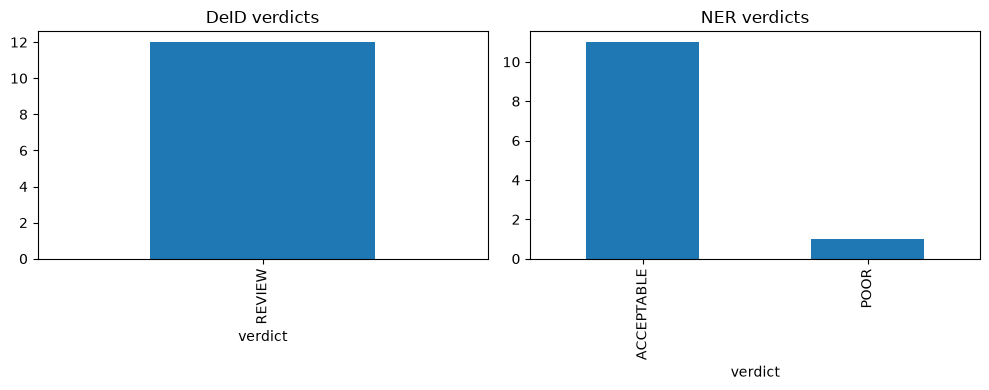

Feedback saved to outputs/feedback/


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ------------------------
# DeID results
# ------------------------
if deid_results:
    df_d = pd.DataFrame(deid_results)

    df_d["verdict"].value_counts().plot.bar(
        ax=axes[0],
        title="DeID verdicts"
    )

    display(
        df_d[
            [
                "note_id",
                "verdict",
                "confidence",
                "note"
            ]
        ]
    )
else:
    axes[0].set_title("DeID verdicts")
    axes[0].text(
        0.5,
        0.5,
        "No DeID results",
        ha="center",
        va="center"
    )


# ------------------------
# NER results
# ------------------------
if ner_results:
    df_n = pd.DataFrame(ner_results)

    df_n["verdict"].value_counts().plot.bar(
        ax=axes[1],
        title="NER verdicts"
    )

    display(
        df_n[
            [
                "note_id",
                "verdict",
                "confidence",
                "note"
            ]
        ]
    )
else:
    axes[1].set_title("NER verdicts")
    axes[1].text(
        0.5,
        0.5,
        "No NER results",
        ha="center",
        va="center"
    )

plt.tight_layout()
plt.show()

print("Feedback saved to outputs/feedback/")

In [6]:
### TODO : ADD MORE EVALUATION METRICS (e.g., precision, recall, F1) AND VISUALIZATIONS FOR NER AND DEID RESULTS